In [15]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set(style='whitegrid',font_scale=2)
import os
import pickle
import time
os.chdir(os.getcwd())
os.getcwd()
from itables import init_notebook_mode
init_notebook_mode(connected=True,all_interactive=True)

#### Create subsetted data from all TB-PACTS dataset for TTP predictions
##### 1. Load datasets:
<br> microbiological            (mb)<br>
<br> demographic                (dm)<br>
<br> pharmacokinetic            (pc)<br>
<br> vital signs                (vs)<br>
<br> radiological               (re)<br>
<br> blood work                 (lb)<br>
<br> medical history            (mh)<br>
<br> clinical events            (ce)<br>
<br> concomitant medication     (cm)<br>
<br> microb. susceptibility     (ms)<br>
<br> adverse events             (ae)<br>
<br> substance use              (su)<br>


#### 2.Subset dataset containing only patients with pharmacokinetic measurements
##### Name of subsetted datasets:  ttp_ds_name

In [2]:
os.getcwd()

'/data/gpfs/projects/punim2121/C-Path/outcome_prediction/outcome_prediction'

In [16]:
#LOAD THE PATIENTS FOR ANALYSIS
patients_for_analyis=pd.read_csv('../data/patients_in_analysis.csv.gz',index_col=0)
ms=pd.read_csv('../../C-Path_data/preprocessing/ms_preprocessed.csv',low_memory=False)

In [17]:
ms

STUDYID DOMAIN          USUBJID     SPDEVID  MSSEQ MSGRPID  MSREFID   
0      TB-1021     MS  TB-1021/2223587  HAINMTBDR+      1     NaN  1800233  \
1      TB-1021     MS  TB-1021/2218157  HAINMTBDR+      1     NaN  1200900   
2      TB-1021     MS  TB-1021/2356725  HAINMTBDR+      1     NaN  0500503   
3      TB-1021     MS  TB-1021/2667293  HAINMTBDR+      1     NaN  0501390   
4      TB-1021     MS  TB-1021/2239522  HAINMTBDR+      1     NaN  0500196   
...        ...    ...              ...         ...    ...     ...      ...   
78715  TB-1001     MS     TB-1001/0213         NaN     11     NaN      NaN   
78716  TB-1001     MS     TB-1001/0814         NaN     13     NaN      NaN   
78717  TB-1001     MS     TB-1001/0814         NaN     13     NaN      NaN   
78718  TB-1001     MS     TB-1001/1002         NaN     17     NaN      NaN   
78719  TB-1001     MS     TB-1001/1002         NaN     17     NaN      NaN   

      MSSPID MSLNKID                       NHOID  ... MSEVINTX MEDIATYP   
0        NaN     NaN  MYCOBACTERIUM TUBERCULOSIS  ...      NaN      NaN  \
1        NaN     NaN  MYCOBACTERIUM TUBERCULOSIS  ...      NaN      NaN   
2        NaN     NaN  MYCOBACTERIUM TUBERCULOSIS  ...      NaN      NaN   
3        NaN     NaN  MYCOBACTERIUM TUBERCULOSIS  ...      NaN      NaN   
4        NaN     NaN  MYCOBACTERIUM TUBERCULOSIS  ...      NaN      NaN   
...      ...     ...                         ...  ...      ...      ...   
78715    NaN     NaN  MYCOBACTERIUM TUBERCULOSIS  ...      NaN      NaN   
78716    NaN     NaN  MYCOBACTERIUM TUBERCULOSIS  ...      NaN      NaN   
78717    NaN     NaN  MYCOBACTERIUM TUBERCULOSIS  ...      NaN      NaN   
78718    NaN     NaN  MYCOBACTERIUM TUBERCULOSIS  ...      NaN      NaN   
78719    NaN     NaN  MYCOBACTERIUM TUBERCULOSIS  ...      NaN      NaN   

      COMMENT                 STD_MSTEST STD_NUM_RESULT STD_CAT_RESULT SV_DAY   
0         NaN  Molecular Drug Resistance            NaN      RESISTANT    NaN  \
1         NaN  Molecular Drug Resistance            NaN      RESISTANT    NaN   
2         NaN  Molecular Drug Resistance            NaN      RESISTANT    NaN   
3         NaN  Molecular Drug Resistance            NaN      RESISTANT    NaN   
4         NaN  Molecular Drug Resistance            NaN      RESISTANT    NaN   
...       ...                        ...            ...            ...    ...   
78715     NaN   Microbial Susceptibility            NaN    SUSCEPTIBLE    NaN   
78716     NaN   Microbial Susceptibility            NaN    SUSCEPTIBLE    NaN   
78717     NaN   Microbial Susceptibility            NaN    SUSCEPTIBLE    NaN   
78718     NaN   Microbial Susceptibility            NaN    SUSCEPTIBLE    NaN   
78719     NaN   Microbial Susceptibility            NaN    SUSCEPTIBLE    NaN   

         STD_MSAGENT STD_MSDY  STD_CAT_ORDINAL_RESULT  
0          Isoniazid    -11.0                     1.0  
1          Isoniazid     -9.0                     1.0  
2          Isoniazid     -8.0                     1.0  
3          Isoniazid     -8.0                     1.0  
4          Isoniazid     -7.0                     1.0  
...              ...      ...                     ...  
78715    Capreomycin    102.0                     0.0  
78716    Capreomycin    121.0                     0.0  
78717   Pyrazinamide    121.0                     0.0  
78718    Capreomycin    268.0                     0.0  
78719      Kanamycin    268.0                     0.0  

[78720 rows x 47 columns]

<Axes: >

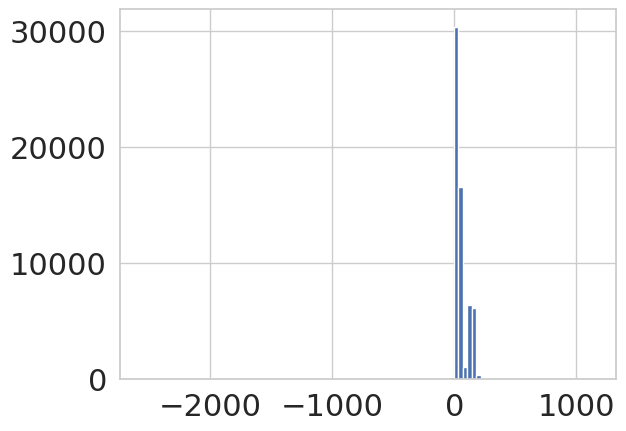

In [8]:
lb[lb['STUDYID']=='TB-1022']['LBDY']#.hist(bins=100)

In [22]:
#LOAD THE PATIENTS FOR ANALYSIS
patients_for_analyis=pd.read_csv('../data/patients_in_analysis.csv.gz',index_col=0)

# LOAD THE WHOLE DATASETS FOR SUBSETTING
mb=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/mb_with_results_days_arms.csv',low_memory=False)
dm=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/dm.csv',low_memory=False)
pc=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/pc.csv',low_memory=False)
vs=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/vs.csv',low_memory=False)
re=pd.read_csv('../../C-Path_data/preprocessing/re_standardised.csv',low_memory=False)
lb=pd.read_csv('../../C-Path_data/preprocessing/lb_cleaned_up_terms.csv',low_memory=False)
mh=pd.read_csv('../../C-Path_data/preprocessing/mh_cleaned_up_terms.csv',low_memory=False)
ce=pd.read_csv('../../C-Path_data/preprocessing/ce_cleaned_up_terms.csv',low_memory=False)
cm=pd.read_csv('../../C-Path_data/preprocessing/cm_cleaned_up_terms.csv',low_memory=False)
ms=pd.read_csv('../../C-Path_data/preprocessing/ms_preprocessed.csv',low_memory=False)
ae=pd.read_csv('../../C-Path_data/preprocessing/ae_cleaned_up_terms.csv',low_memory=False)
su=pd.read_csv('../../C-Path_data/preprocessing/su_standardised.csv',low_memory=False)


## Subset dataframes

In [18]:
try:
    #filter out NOT DONE measurements
    ds_list=[pc,vs,lb,ms,ce,mh]
    col_names=['PCSTAT','VSSTAT','LBSTAT','MSSTAT','CESTAT','MHSTAT']
    for ds,col in zip(ds_list,col_names):
        ds.drop(index=ds[~ds[col].isna()].index,inplace=True)
except NameError:
    pass


#get patient ids for analysis

pat_ids_for_analysis=patients_for_analyis['USUBJID'].tolist()

#Subset datasets containing only necessary patients and save them
#datasets=[mb,dm,pc,vs,re,lb,mh,ce,cm,ms,ae,su]
#datasets_name=['mb','dm','pc','vs','re','lb','mh','ce','cm','ms','ae','su']

datasets=[ms]
datasets_name=['ms']

for ds,ds_name in zip(datasets,datasets_name):
    ds['USUBJID'] = ds['USUBJID'].str.replace('\\', '/', regex=False)
    try:
        ds=ds.drop(index=ds[ds['USUBJID'].apply(lambda x:x not in pat_ids_for_analysis)].index)
    except KeyError:
        print(ds_name)
        ds=ds.drop(index=ds[ds['Study'].apply(lambda x:x not in pat_ids_for_analysis)].index)
    ds=ds.dropna(how='all',axis=1)        
    ds.to_csv('../data/out_'+ds_name+'.csv.gz',compression='gzip',index=None)
    #ds.to_parquet('../data/out_'+ds_name+'.parquet',index=None)


In [11]:
mh.loc[mh['STUDYID'].isin(['TB-1021','TB-1022']),'MHOCCUR'].dropna()

Series([], Name: MHOCCUR, dtype: object)

In [20]:
ds

(37287, 33)

In [22]:
ms.shape

(78720, 47)